In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def surface_green_L(AL, TL, max_iter=1000, tol=1e-6):
    G_surface = np.linalg.inv(AL)

    for i in range(max_iter):
        sigma = TL @ G_surface @ TL.conj().T
        G_new = np.linalg.inv(AL - sigma)

        diff_sum = np.sum(np.abs(G_new - G_surface))
        if diff_sum < tol:
            break
        G_surface = G_new
    return G_surface


def G_kk_corrected(J,k,ALR,TL,SEGMAR):

    G_result = np.zeros((J, J, k, k), dtype=complex)

    for i in range(J):
        if i == 0:
            G_result[i, i] = np.linalg.inv(ALR-SEGMAR)
        
        elif 0 < i <= J-2:
            G_result[i, i] = np.linalg.inv(ALR- TL @ G_result[i-1, i-1] @ TL)
            G_result[0, i] = G_result[0, i-1] @ TL @ G_result[i, i]
        
        elif i == J-1:
            AA = ALR- TL @ G_result[i-1, i-1] @ TL - SEGMAR
            G_result[i, i] = np.linalg.inv(AA)
            G_result[0, i] = G_result[0, i-1] @ T00 @ G_result[i, i]
    return G_result

def H_00(t, Vt, k):   
    H_matrix = np.zeros((k, k), dtype=complex)
    for i in range(k):
        if i == 0:
            H_matrix[i, i], H_matrix[i, i+1] = Vt + 4*t, -t
        elif i == k-1:
            H_matrix[i, i-1], H_matrix[i, i] = -t, Vt + 4*t
        else:  
            H_matrix[i, i-1], H_matrix[i, i], H_matrix[i, i+1] = -t, Vt + 4*t, -t
    return H_matrix

def T_DL(t, k):   
    T_matrix = np.zeros((k, k), dtype=complex)
    for i in range(k):
        if i == 0:
            T_matrix[i, i+1] = t
        elif i == k-1:
            T_matrix[i, i-1] = t
        else:  
            T_matrix[i, i-1], T_matrix[i, i+1] = t, t
    return T_matrix

# 参数设置
t = 1
Vt = 2
k = 10
J = 20
NJ = 1e-5
E=1

# 构建哈密顿量/跃迁矩阵
H00 = H_00(t, Vt, k)
ALR=(E+NJ*1j)*np.eye(k)-H00
ALA=(E-NJ*1j)*np.eye(k)-H00
TL=T_DL(t, k)

 # 计算自能
SEGMAR= t * surface_green_L(ALR, TL) * t
SEGMAA=t *  surface_green_L(ALA, TL) * t

# 计算Γ矩阵
GAMA11 = 1j * (SEGMAR - SEGMAA)
GAMANN = GAMA11.copy()

# 计算格林函数
G1N = G_kk_corrected(J,k,ALR,TL,SEGMAR)[0 , J-1]

# 计算迹（电导正比于Trace[Γ_l G Γ_r G†]）
GT = GAMA11 @ G1N @ GAMANN @ np.conj(G1N.T)
trace = np.trace(GT)




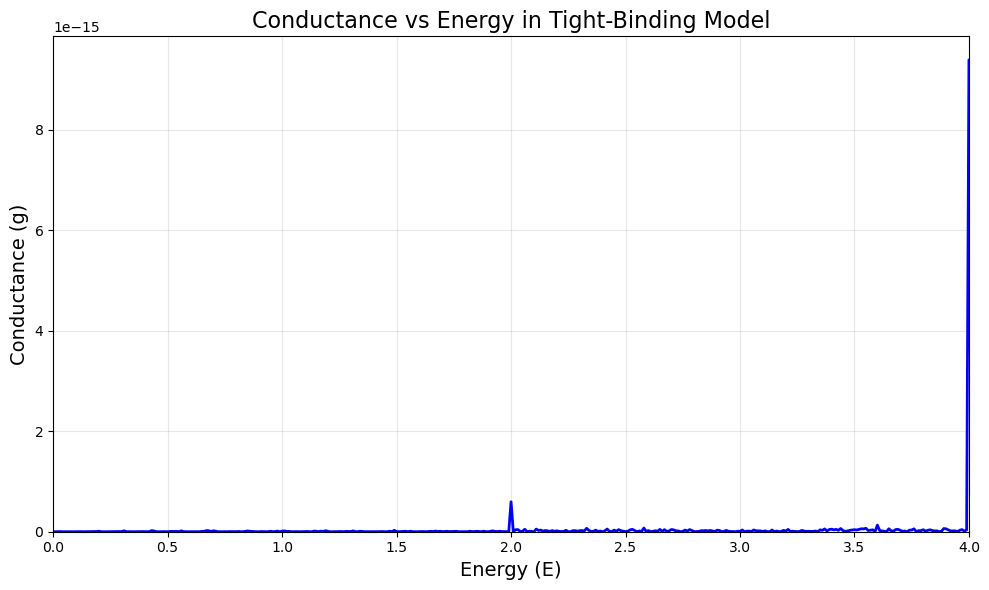

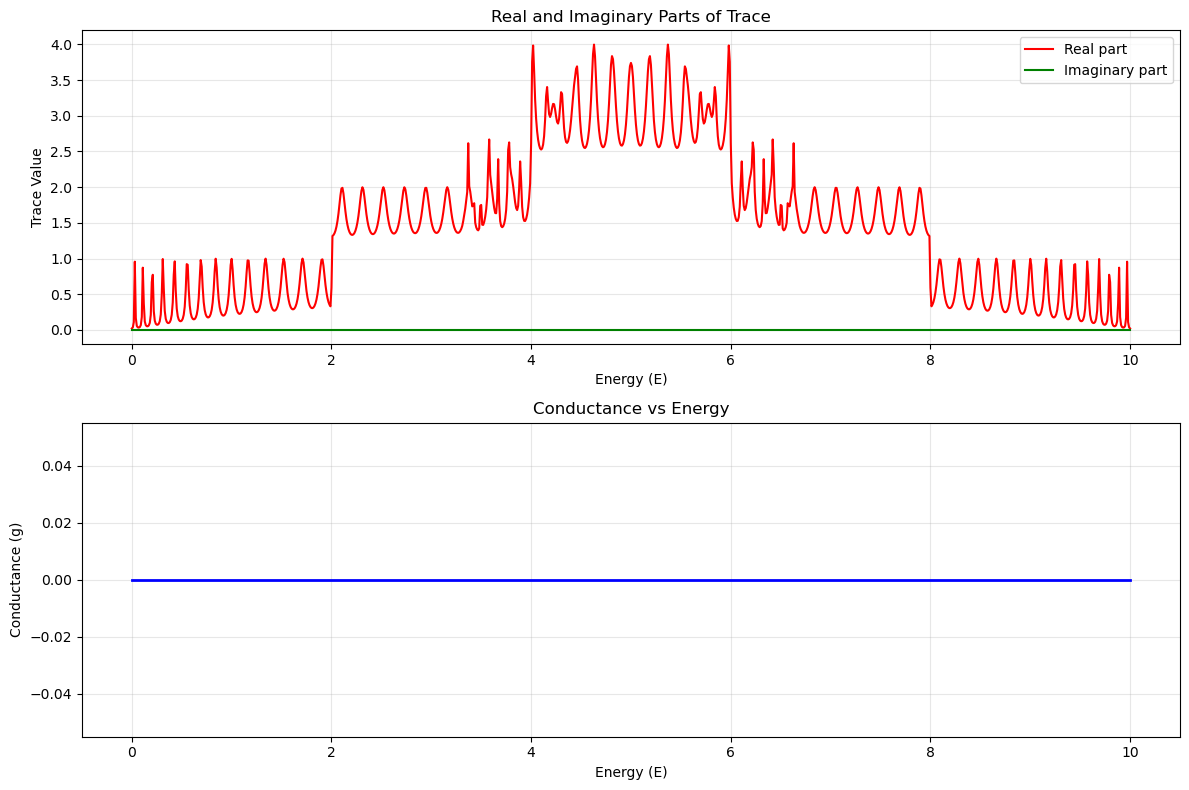

In [19]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# 参数设置
U = 1
T = 1.0
ITA = 1e-5  # 无穷小值
N = 50      # X方向网格点数
M = 5       # Y方向网格点数

def f1(AL, TL):
    """计算表面格林函数"""
    GS1 = np.linalg.inv(AL)  # 表面格林函数的初始值
    IC = 0
    while True:
        MATRIX1 = TL @ GS1 @ TL
        GSO = np.linalg.inv(AL - MATRIX1)
        GS1 = 0.5 * GSO + 0.5 * GS1
        IC += 1
        if IC > 1000:
            break
    return GSO

def f2(TL, ALR, SEGMAR):
    """计算格林函数"""
    # 初始化格林函数
    G11 = np.linalg.inv(ALR - SEGMAR)
    matrix1 = ALR - TL @ G11 @ TL
    G22 = np.linalg.inv(matrix1)
    G12 = G11 @ TL @ G22
    
    # 迭代计算
    for _ in range(N - 3):
        matrix2 = ALR - TL @ G22 @ TL
        G33 = np.linalg.inv(matrix2)
        G13 = G12 @ TL @ G33
        G12 = G13
        G22 = G33
    
    # 最终计算
    matrix4 = ALR - SEGMAR - TL @ G33 @ TL
    matrix5 = np.linalg.inv(matrix4)
    G1N = G13 @ TL @ matrix5
    
    return G1N

def main():
    # 初始化矩阵
    HA = np.zeros((M, M))
    TL = np.zeros((M, M))
    
    # 构建哈密顿量和跃迁矩阵
    for i in range(M):
        HA[i, i] = U + 4.0 * T
        if i < M - 1:
            HA[i, i+1] = -T
            HA[i+1, i] = -T
            TL[i, i+1] = T
            TL[i+1, i] = T
    
    # 存储结果
    energies = []
    conductances = []
    
    # 打开输出文件
    with open('NEGF_out.txt', 'w') as f:
        # 能量循环
        for E in np.arange(0, 10.01, 0.01):
            # 构建左/右自能矩阵
            ALR = np.zeros((M, M), dtype=complex)
            ALA = np.zeros((M, M), dtype=complex)
            
            for i in range(M):
                ALR[i, i] = E + 1j * ITA - U - 4 * T
                ALA[i, i] = E - 1j * ITA - U - 4 * T
                if i < M - 1:
                    ALR[i, i+1] = T
                    ALR[i+1, i] = T
                    ALA[i, i+1] = T
                    ALA[i+1, i] = T
            
            # 计算表面格林函数
            GSR = f1(ALR, TL)
            GSA = f1(ALA, TL)
            
            # 计算自能
            SEGMAR = T * T * GSR
            SEGMAA = T * T * GSA
            
            # 计算Γ矩阵
            GAMA11 = 1j * (SEGMAR - SEGMAA)
            GAMANN = GAMA11.copy()
            
            # 计算格林函数
            G1N = f2(TL, ALR, SEGMAR)
            
            # 计算迹（电导正比于Trace[Γ_l G Γ_r G†]）
            GT = GAMA11 @ G1N @ GAMANN @ np.conj(G1N.T)
            trace = np.trace(GT)
            
            # 电导g（朗道尔公式，正比于迹的虚部）
            # 实际电导为 (e²/h) * Trace[Γ_l G Γ_r G†]
            conductance = np.abs(trace.imag)  # 取绝对值或直接使用虚部
            
            # 存储数据
            energies.append(E)
            conductances.append(conductance)
            
            # 写入结果
            x = trace.real
            y = trace.imag
            f.write(f"{E:.6f} {x:.12f} {y:.12f} {conductance:.12f}\n")
    
    # 绘制电导-能量图
    plt.figure(figsize=(10, 6))
    plt.plot(energies, conductances, 'b-', linewidth=2)
    plt.xlabel('Energy (E)', fontsize=14)
    plt.ylabel('Conductance (g)', fontsize=14)
    plt.title('Conductance vs Energy in Tight-Binding Model', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 4)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.savefig('conductance_vs_energy.png', dpi=300)
    plt.show()
    
    # 也可以绘制实部和虚部
    plt.figure(figsize=(12, 8))
    
    # 读取文件数据绘制更多细节
    data = np.loadtxt('NEGF_out.txt')
    E_vals = data[:, 0]
    real_part = data[:, 1]
    imag_part = data[:, 2]
    cond_vals = data[:, 3]
    
    plt.subplot(2, 1, 1)
    plt.plot(E_vals, real_part, 'r-', label='Real part')
    plt.plot(E_vals, imag_part, 'g-', label='Imaginary part')
    plt.xlabel('Energy (E)')
    plt.ylabel('Trace Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title('Real and Imaginary Parts of Trace')
    
    plt.subplot(2, 1, 2)
    plt.plot(E_vals, cond_vals, 'b-', linewidth=2)
    plt.xlabel('Energy (E)')
    plt.ylabel('Conductance (g)')
    plt.title('Conductance vs Energy')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('detailed_analysis.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    main()